# WP2 — the interferon-alpha domain: statistics and figure panels

Reviewer major comment 2: *"…do not compare this to genome-wide background or to matched
random regions. Please perform a statistical test (e.g., permutation test)… Also, please
report the number of L1 elements in this region and their specific subfamilies."*

All four tests are computed by `02_ifna_domain_test.py`; this notebook **reads its output
and renders it**, so the numbers on screen are the numbers in the CSVs and nothing is
recomputed at plotting time.

The domain is **chr9:21,150,692–21,370,055** (219,363 bp) in T2T-CHM13.

**New main Figure 8** (promoting the old Supplementary Figure 6):
* **8A** — the existing UCSC browser view, Figma frame `861:29` (vector, unchanged)
* **8B** — null distributions for tests 1–3 with the observed value marked → written here
* **8C** — L1 subfamily composition and per-element divergence → written here

There is no panel D: decision **D4** removed the planned chromatin panel.

In [1]:
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

sys.path.insert(0, os.path.abspath("."))
import revision_lib as rl

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({"font.size": rl.GLOBAL_FONT_SIZE})
os.makedirs(rl.SVG_DIR, exist_ok=True)

OUT = rl.OUTPUT_DIR
tests = pd.read_csv(os.path.join(OUT, "ifna_test_results.csv"))
nulls = pd.read_csv(os.path.join(OUT, "ifna_null_distributions.csv"))
elements = pd.read_csv(os.path.join(OUT, "ifna_window_elements.csv"))
composition = pd.read_csv(os.path.join(OUT, "ifna_subfamily_composition.csv"))
qc = json.load(open(os.path.join(OUT, "ifna_qc.json")))

# Young primate-specific L1 vs older mammalian L1M*, the split test 4 uses.
AGE_COLOURS = {"young_primate": "#cc660b", "old_mammalian": "#9a9a9a"}

## 1. The four test results, for review before anything is plotted

`empirical_p_two_sided` is a **raw** empirical permutation p-value (one test per row, no
correction applied — it is reported as such in the figure and the caption). Test 4 is a
raw two-sided Fisher exact p.

In [2]:
show = tests[["test", "observed", "n_null_windows", "null_mean", "null_sd",
              "z_score", "empirical_p_two_sided", "empirical_p_floor", "at_floor"]]
print(show.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print()
for row in tests.itertuples():
    print(f"{row.test}\n    {row.description}\n    statistic: {row.statistic}")
print(f"\nQC (caveat C7): {qc['qc_note_C7']}")
print(f"mean L1 divergence in window {qc['mean_l1_divergence_window']} | "
      f"excluding the divergence-0 element {qc['mean_l1_divergence_window_excl_zero']} | "
      f"excluding the 5 youngest {qc['mean_l1_divergence_window_excl_5_youngest']}")
print(f"genome-wide L1 mean {qc['mean_l1_divergence_genome']}, "
      f"median {qc['median_l1_divergence_genome']}")

                              test  observed  n_null_windows  null_mean  null_sd  z_score  empirical_p_two_sided  empirical_p_floor  at_floor
           T1_divergence_unmatched     135.7           1e+04      189.4    23.59   -2.276                 0.0224             0.0002     False
    T2_divergence_L1_count_matched     135.7           1e+04      189.2    17.42   -3.074               0.006099             0.0002     False
T3_divergence_gene_density_matched     135.7            3582      204.5    22.83   -3.015               0.001675          0.0005582     False
          T4_subfamily_composition      3.01             NaN     0.3237      NaN      NaN              3.207e-06                NaN     False

T1_divergence_unmatched
    Mean L1 divergence vs random 220 kb autosomal windows with >= 1 L1
    statistic: empirical permutation p (two-sided), raw
T2_divergence_L1_count_matched
    Mean L1 divergence vs random windows with >= 40 L1 (controls for L1 density)
    statistic: empirical p

## 2. The descriptive inventory the reviewer asked for

175 TEs, of which **77 are L1** (44 %), spanning **36 distinct L1 subfamilies** — which is
the direct answer to "not driven by a few outliers".

In [3]:
print(f"TEs in the {qc['domain_length_bp']:,} bp domain: {qc['n_tes_in_window']}")
print(f"L1 elements: {qc['n_l1_in_window']} ({100 * qc['l1_fraction_of_window_tes']:.0f} %)")
print(f"distinct L1 subfamilies: {qc['n_distinct_l1_subfamilies']}")
print(f"L1 density: {qc['l1_per_mb_window']} / Mb in the window vs "
      f"{qc['l1_per_mb_genome']} / Mb genome-wide = {qc['l1_density_ratio']}x")
print(f"genes in the window ({qc['n_genes_in_window']}): {', '.join(qc['genes_in_window'])}")
pd.Series(qc["family_composition"]).to_frame("elements")

TEs in the 219,363 bp domain: 175
L1 elements: 77 (44 %)
distinct L1 subfamilies: 36
L1 density: 351.0 / Mb in the window vs 181.4 / Mb genome-wide = 1.94x
genes in the window (12): IFNA10, IFNA14, IFNA16, IFNA17, IFNA21, IFNA22P, IFNA4, IFNA5, IFNA6, IFNA7, IFNW1, KLHL9


,elements
L1,77
Alu,33
L2,15
MIR,13
hAT-Charlie,11
ERV1,10
ERVL-MaLR,6
MULE-MuDR,3
TcMar-Tigger,2
PiggyBac,1


## 3. Panel 8B — null distributions for tests 1–3

One row per test. Grey histogram = the null; the coloured line = the observed mean
divergence of the 77 window L1s. Test 3 draws fewer null windows than tests 1–2 because
only ~3 % of the genome carries ≥ 10 genes in 220 kb; the actual count is printed on each
panel rather than implied.

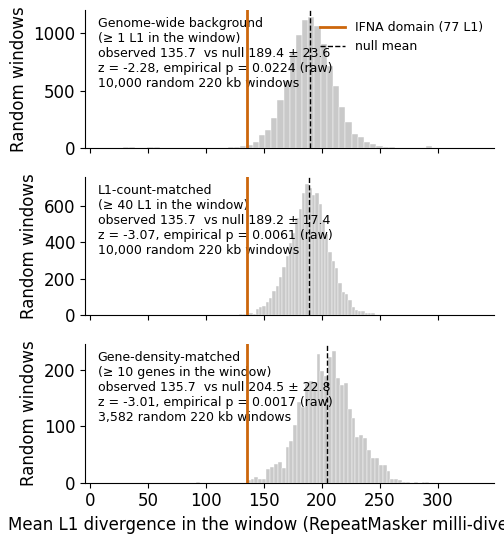

In [4]:
TEST_LABELS = {
    "T1_divergence_unmatched": "Genome-wide background\n(≥ 1 L1 in the window)",
    "T2_divergence_L1_count_matched": "L1-count-matched\n(≥ 40 L1 in the window)",
    "T3_divergence_gene_density_matched": "Gene-density-matched\n(≥ 10 genes in the window)",
}
divergence_tests = [t for t in TEST_LABELS if t in set(nulls["test"])]

fig, axes = plt.subplots(len(divergence_tests), 1, figsize=(5.2, 5.6), sharex=True)
axes = np.atleast_1d(axes)

for ax, test_name in zip(axes, divergence_tests):
    row = tests[tests["test"] == test_name].iloc[0]
    values = nulls.loc[nulls["test"] == test_name, "null_mean_l1_divergence"].to_numpy()

    ax.hist(values, bins=60, color="#c9c9c9", edgecolor="white", linewidth=0.3)
    ax.axvline(row.observed, color="#cc660b", lw=2.0, zorder=5)
    ax.axvline(row.null_mean, color="black", lw=1.0, ls="--", zorder=4)

    ax.text(
        0.03, 0.95,
        f"{TEST_LABELS[test_name]}\n"
        f"observed {row.observed:.1f}  vs null {row.null_mean:.1f} ± {row.null_sd:.1f}\n"
        f"z = {row.z_score:.2f}, empirical p = {row.empirical_p_two_sided:.4f} (raw)\n"
        f"{int(row.n_null_windows):,} random 220 kb windows",
        transform=ax.transAxes, va="top", ha="left", fontsize=rl.fs(7.5),
    )
    ax.set_ylabel("Random windows")
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Mean L1 divergence in the window (RepeatMasker milli-divergence)")
axes[0].legend(
    handles=[
        Line2D([], [], color="#cc660b", lw=2.0, label="IFNA domain (77 L1)"),
        Line2D([], [], color="black", lw=1.0, ls="--", label="null mean"),
    ],
    frameon=False, fontsize=rl.fs(7.5), loc="upper right",
)
fig.tight_layout()
fig.savefig(os.path.join(rl.SVG_DIR, "Fig8B_null_distributions.svg"),
            format="svg", transparent=True, bbox_inches="tight")
plt.show()

## 4. Panel 8C — L1 subfamily composition and per-element divergence

Left: elements per subfamily, ordered by mean divergence, coloured by age clade. Right:
every individual L1 as a point against the genome-wide L1 mean, so the reader can see the
signal is carried by many elements rather than by the youngest few. The trimmed statistics
printed in section 1 are the quantitative version of the same point.

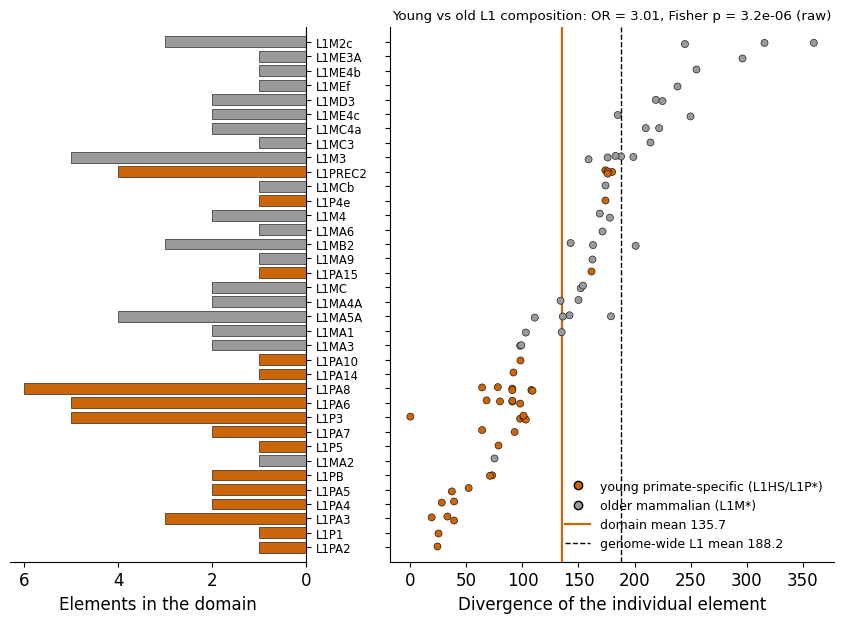

In [5]:
l1_elements = elements[elements["family_name"] == "L1"].copy()
YOUNG_PREFIXES = ("L1HS", "L1P")
l1_elements["age_group"] = np.where(
    l1_elements["subfamily_name"].str.startswith(YOUNG_PREFIXES),
    "young_primate", "old_mammalian",
)
order = composition.sort_values("mean_divergence")["subfamily_name"].tolist()

fig, (ax_bar, ax_strip) = plt.subplots(
    1, 2, figsize=(8.6, 6.4), gridspec_kw={"width_ratios": [1.0, 1.5]}, sharey=True
)

bars = composition.set_index("subfamily_name").loc[order]
ax_bar.barh(
    range(len(order)), bars["n"].to_numpy(),
    color=[AGE_COLOURS[g] for g in bars["age_group"]],
    edgecolor="black", linewidth=0.4, height=0.75,
)
ax_bar.set_yticks(range(len(order)))
ax_bar.set_yticklabels(order, fontsize=rl.fs(7))
ax_bar.set_xlabel("Elements in the domain")
ax_bar.invert_xaxis()
ax_bar.yaxis.tick_right()
ax_bar.spines[["top", "left"]].set_visible(False)

rng = np.random.default_rng(42)
for i, subfamily in enumerate(order):
    part = l1_elements[l1_elements["subfamily_name"] == subfamily]
    jitter = rng.uniform(-0.18, 0.18, len(part))
    ax_strip.scatter(
        part["score"], np.full(len(part), i) + jitter,
        s=26, color=[AGE_COLOURS[g] for g in part["age_group"]],
        edgecolor="black", linewidth=0.4, zorder=3,
    )

ax_strip.axvline(qc["mean_l1_divergence_genome"], color="black", lw=1.0, ls="--", zorder=2)
ax_strip.axvline(qc["mean_l1_divergence_window"], color="#cc660b", lw=1.6, zorder=2)
ax_strip.set_xlabel("Divergence of the individual element")
ax_strip.set_ylim(-1, len(order))
ax_strip.spines[["top", "right"]].set_visible(False)
ax_strip.legend(
    handles=[
        Line2D([], [], marker="o", ls="", markerfacecolor=AGE_COLOURS["young_primate"],
               markeredgecolor="black", label="young primate-specific (L1HS/L1P*)"),
        Line2D([], [], marker="o", ls="", markerfacecolor=AGE_COLOURS["old_mammalian"],
               markeredgecolor="black", label="older mammalian (L1M*)"),
        Line2D([], [], color="#cc660b", lw=1.6,
               label=f"domain mean {qc['mean_l1_divergence_window']:.1f}"),
        Line2D([], [], color="black", lw=1.0, ls="--",
               label=f"genome-wide L1 mean {qc['mean_l1_divergence_genome']:.1f}"),
    ],
    frameon=False, fontsize=rl.fs(7.5), loc="lower right",
)

fisher = tests[tests["test"] == "T4_subfamily_composition"].iloc[0]
ax_strip.set_title(
    f"Young vs old L1 composition: OR = {fisher.observed:.2f}, "
    f"Fisher p = {fisher.empirical_p_two_sided:.1e} (raw)", fontsize=rl.fs(8),
)
fig.tight_layout()
fig.savefig(os.path.join(rl.SVG_DIR, "Fig8C_subfamily_composition.svg"),
            format="svg", transparent=True, bbox_inches="tight")
plt.show()

## 5. Robustness, as a figure-ready inset

Leave-one-out means and the two trimmed means, all still far below the null mean. This is
what turns "not driven by a few outliers" into something a reader can check.

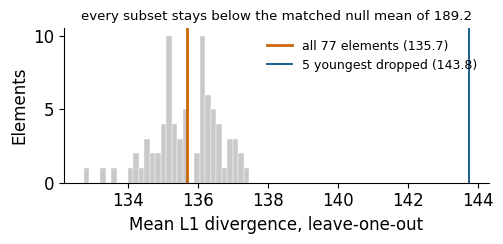

leave-one-out range: 132.7 – 137.5


In [6]:
scores = l1_elements["score"].to_numpy(dtype=float)
loo = np.array([np.delete(scores, i).mean() for i in range(len(scores))])
null_mean_t2 = float(
    tests.loc[tests["test"] == "T2_divergence_L1_count_matched", "null_mean"].iloc[0]
)

fig, ax = plt.subplots(figsize=(5.2, 2.6))
ax.hist(loo, bins=30, color="#c9c9c9", edgecolor="white", linewidth=0.3)
ax.axvline(scores.mean(), color="#cc660b", lw=2.0,
           label=f"all 77 elements ({scores.mean():.1f})")
ax.axvline(qc["mean_l1_divergence_window_excl_5_youngest"], color="#195f90", lw=1.4,
           label=f"5 youngest dropped "
                 f"({qc['mean_l1_divergence_window_excl_5_youngest']:.1f})")
ax.set_xlabel("Mean L1 divergence, leave-one-out")
ax.set_ylabel("Elements")
ax.set_title(f"every subset stays below the matched null mean of {null_mean_t2:.1f}",
             fontsize=rl.fs(8))
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=rl.fs(7.5))
fig.tight_layout()
fig.savefig(os.path.join(rl.SVG_DIR, "Fig8C_inset_leave_one_out.svg"),
            format="svg", transparent=True, bbox_inches="tight")
plt.show()
print(f"leave-one-out range: {loo.min():.1f} – {loo.max():.1f}")

## 6. SVGs written

In [7]:
for name in sorted(os.listdir(rl.SVG_DIR)):
    if name.startswith("Fig8"):
        path = os.path.join(rl.SVG_DIR, name)
        print(f"  {name:44s} {os.path.getsize(path):>8,} B   -> new main Figure 8")
print("\n8A is the existing vector UCSC panel in Figma frame 861:29 — not regenerated.")

  Fig8B_null_distributions.svg                   70,103 B   -> new main Figure 8
  Fig8C_inset_leave_one_out.svg                  17,251 B   -> new main Figure 8
  Fig8C_subfamily_composition.svg                76,655 B   -> new main Figure 8

8A is the existing vector UCSC panel in Figma frame 861:29 — not regenerated.
